In [5]:
import wandb

import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt

import numpy as np 

from xaikd import models, datasets

from torch.utils.data import DataLoader
from xaikd.utils import metrics

In [6]:
api = wandb.Api()

In [7]:
EXPERIMENT_GROUP = "tmp/remove-bn-run13--comparison-ortho-basis-student-transform"

In [71]:
def read_data(
    teacher,
    student,
    policy,
    lambda_task,
    lambda_kd,
    lambda_layer,
    basis_mode,
    dataset,
    training_size,
    verbose=False,
    
    
):
    
    
    
    runs = api.runs(
        f'p16i/xaikd-distillation-layerwise',
        {
        "$and": [
            {"group": EXPERIMENT_GROUP},
            {"config.teacher": teacher},
            {"config.student": student},
            
            {"config.lambda_task": lambda_task},
            {"config.lambda_kd": lambda_kd},
            {"config.lambda_layer": lambda_layer},
            
            {"config.policy": {"$in": [policy]}},
            {"config.training_size": training_size},
            {"config.dataset": dataset},
            {"config.basis_mode": basis_mode},
        ]}
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    
    assert len(runs) == 1
    
    
    return runs[0]

#     rows = []
    
#     for run in runs:
#         seed = run.config["seed"]
                         
#         k = np.argmax(run.summary["arr_metrics"]["val_acc"]["value"])
#         best_val_acc = run.summary["arr_metrics"]["val_acc"]["value"][k]
#         best_val_agreement = run.summary["arr_metrics"]["val_agreement"]["value"][k]
#         best_val_agreement_on_teacher_correct = run.summary["arr_metrics"]["val_agreement_on_teacher_correct"]["value"][k]


#         rows.append(
#             dict(
#                 seed=seed, 
#                 layers=run.config["layers"],
#                 lambda_kd=run.config["lambda_kd"],
#                 lambda_layer=run.config["lambda_layer"],
#                 epoch=run.summary["arr_metrics"]["val_acc"]["values"]
#                 val_acc=best_val_acc, 
#                 val_agreement=best_val_agreement,
#                 val_agreement_on_teacher_correct=best_val_agreement_on_teacher_correct,
#                 teacher_acc=run.summary["teacher_acc"],
#                 policy=run.config["policy"]
#             )
#         )

    
#     df = pd.DataFrame(rows)
        
#     df = df.groupby(by="epoch").agg(
#         {
#             "val_acc": ["mean", "std", "count"],
#             "val_agreement": ["mean", "std", "count"],
#             "val_agreement_on_teacher_correct": ["mean", "std", "count"],
#             "teacher_acc": ["mean"]
#         }
#     ).reset_index()
#     if verbose:
#         print(f"df.shape: {df.shape}")
#     return df

summary = read_data(
    teacher="cifar100-resnet18-wb15",
    student="resnet18cifarcompr2",
    basis_mode="centered",
    lambda_task=0.0,
    lambda_kd=1.0,
    lambda_layer=1.0,
    policy="basis:pca",
#     arr_policies=["basis:pca", "basis-student-linear:pca", "basis-student-identity:pca"],
    training_size=1.0,
    verbose=True,
    dataset="cifar100-people",
    
)

summary;

we have 1 runs


# Comparison on `cifar100-resnet18-wb15`

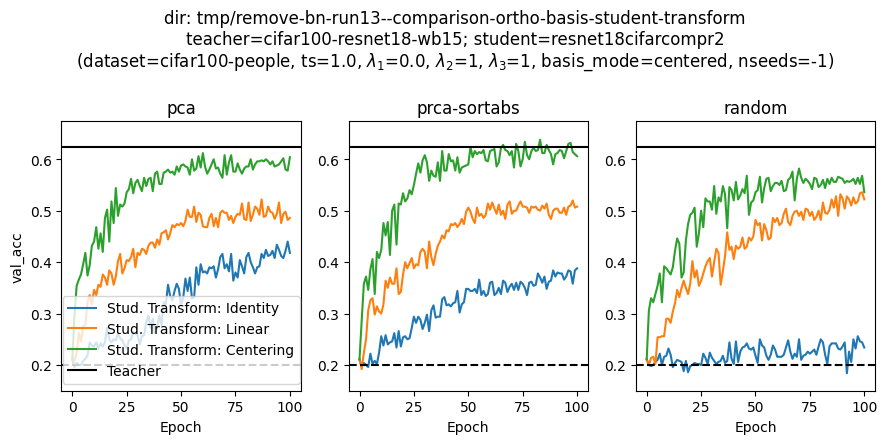

In [74]:
def ls(basis_name):
    if "random" in basis_name:
        return ":"
    elif basis_name == "linstudent":
        return "--"
    else:
        return "-"
    
def color(basis_name):
    if "random" in basis_name:
        return "gray"
    else:
        return None
    
def alias(policy):
    if policy == "basis":
        return "Stud. Transform: Centering"
    elif policy == "basis-student-linear":
        return "Stud. Transform: Linear"
    elif policy == "basis-student-identity":
        return "Stud. Transform: Identity"
    else:
        raise
    
def viz_distillation(teacher, student, basis_mode):
    lambda_layer = lambda_kd = 1
    dataset = "cifar100-people"
    lambda_task = 0.0
    training_size = 1.0
    
    basis_names = [
        "pca",
        "prca-sortabs",
        "random"
    ]
    
    
    policy_prefixes = [ 
        "basis-student-identity",
        "basis-student-linear",
        "basis",
    ]
        
    
  
    
    
    columns = ["val_acc", "val_agreement", "val_agreement_on_teacher_correct"][:1]

    
    ncols = len(basis_names)
    nrows = len(columns)
    
    plt.figure(figsize=(3.5*ncols, 3.5*nrows))
    
    dirslug = "/".join(f"{EXPERIMENT_GROUP}".split("/")[-2:])

    
    for bix, basis_name in enumerate(basis_names):
        
        for rix, col in enumerate(columns):
            plt.subplot(nrows, ncols, bix + rix * ncols + 1)

            
            if rix == 0:
                plt.title(basis_name)
                
            if rix == nrows - 1:
                plt.xlabel("Epoch")

            count = -1
        

            if bix == 0:
                plt.ylabel(col)
                
            
                
            for policy in policy_prefixes:
                run = read_data(
                    teacher=teacher,
                    student=student,
                    lambda_task=lambda_task,
                    lambda_kd=lambda_kd,
                    lambda_layer=lambda_layer,
                    policy=f"{policy}:{basis_name}",
                    dataset=dataset,
                    training_size=training_size,
                    basis_mode=basis_mode,
                )
                
                plt.plot(run.summary["arr_metrics"][col]["value"], label=alias(policy))
            
            teacher_acc = run.summary["teacher_acc"] 

            if col == "val_acc":
                plt.axhline(teacher_acc, ls="-", color="k", label="Teacher")
                plt.axhline(0.2, ls="--", color="k")
                plt.ylim([0.15, teacher_acc+0.05])
            else:
                plt.ylim([0, 1])
                plt.axhline(0.5, ls="--", color="k")
            if bix == 0 and rix == 0:
                plt.legend()

    plt.suptitle(
        "\n".join([
            f"dir: {dirslug}",
            f"teacher={teacher}; student={student}",
            f"(dataset={dataset}, ts={training_size}, $\lambda_1$={lambda_task}, $\lambda_2$={lambda_kd}, $\lambda_3$={lambda_layer}, basis_mode={basis_mode}, nseeds={count})",
        ]),
        y=1.2
    )

viz_distillation(
    teacher = "cifar100-resnet18-wb15",
    student="resnet18cifarcompr2",
    basis_mode="centered"
) 

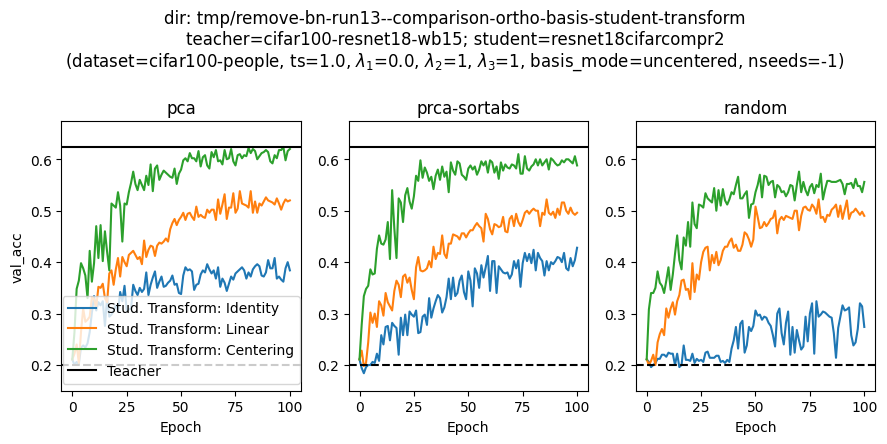

In [75]:
viz_distillation(
    teacher = "cifar100-resnet18-wb15",
    student="resnet18cifarcompr2",
    basis_mode="uncentered"
) 

# Summary

Setup:
$$
 (0.0) \ell_\text{task} + \lambda_2 \ell_\text{KD} + \lambda_3 \ell_\text{layer},
$$
$\lambda_2 = 1$ and $\lambda_3 = 1$


*Aim:*
- investigate how the student transformation affects the performance of the layerwise distillation with orthogonal bases.



*Conclusion:*
- the `Centering` policy (in code `basis`) always leads to better results regardless `basis_model=centered` or `basis_mode=uncentered`. 

- additionally, we can aso see that, when `basis_mode=centered`, `prca-sortabs` performs slighly better than `pca`. The trend is opposite when `basis_mode=uncentered`.